In [1]:
import anndata as ad
import zarr
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
from MisTIC.mistic_class import mistic
from scipy.sparse import csr_matrix
import geopandas as gpd
import os
import spatialdata as sd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon
import seaborn as sns
from spatialdata_io import xenium

/homevol/kk/.local/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/homevol/kk/.local/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


# Merge the TMAs together (placing side-by-side)

In [4]:
sdata_L = xenium("output-XETG00141__0052404__TMA6L__20250611__063424")
sdata_R = xenium("output-XETG00141__0052407__TMA6R__20250611__063425")

INFO     reading                                                                                                   
         /homevol/kk/analysis/OVA_TMA/Old/TMA6_only/from_full_xenium_data/output-XETG00141__0052404__TMA6L__2025061
         1__063424/cell_feature_matrix.h5                                                                          


/tmp/ipykernel_20445/2798647785.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata_L = xenium("/homevol/kk/analysis/OVA_TMA/Old/TMA6_only/from_full_xenium_data/output-XETG00141__0052404__TMA6L__20250611__063424")


INFO     reading                                                                                                   
         /homevol/kk/analysis/OVA_TMA/Old/TMA6_only/from_full_xenium_data/output-XETG00141__0052407__TMA6R__2025061
         1__063425/cell_feature_matrix.h5                                                                          


/tmp/ipykernel_20445/2798647785.py:2: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata_R = xenium("/homevol/kk/analysis/OVA_TMA/Old/TMA6_only/from_full_xenium_data/output-XETG00141__0052407__TMA6R__20250611__063425")


In [5]:
sdata_L

SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (5, 74856, 48431), (5, 37428, 24215), (5, 18714, 12107), (5, 9357, 6053), (5, 4678, 3026)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (74856, 48431), (37428, 24215), (18714, 12107), (9357, 6053), (4678, 3026)
│     └── 'nucleus_labels': DataTree[yx] (74856, 48431), (37428, 24215), (18714, 12107), (9357, 6053), (4678, 3026)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (576334, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (576334, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (567753, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (576334, 480)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries 

In [6]:
sdata_R

SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (5, 74854, 54147), (5, 37427, 27073), (5, 18713, 13536), (5, 9356, 6768), (5, 4678, 3384)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (74854, 54147), (37427, 27073), (18713, 13536), (9356, 6768), (4678, 3384)
│     └── 'nucleus_labels': DataTree[yx] (74854, 54147), (37427, 27073), (18713, 13536), (9356, 6768), (4678, 3384)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (572257, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (572257, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (563963, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (572257, 480)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries 

In [61]:
adata_L = sdata_L.tables["table"]
adata_R = sdata_R.tables["table"]

tx_L = sdata_L.points["transcripts"]
tx_R = sdata_R.points["transcripts"]

polys_L = sdata_L.shapes["cell_boundaries"]
polys_R = sdata_R.shapes["cell_boundaries"]


In [62]:
# Convert to Pandas Xenium tables are already pandas
tx_L = tx_L.compute()
tx_R = tx_R.compute()

# Filter out unassigned transcripts
tx_L = tx_L[tx_L["cell_id"] != "UNASSIGNED"].copy()
tx_R = tx_R[tx_R["cell_id"] != "UNASSIGNED"].copy()


In [63]:
# Compute Y boundaries
y_max_L = adata_L.obsm["spatial"][:,1].max()
y_min_R = adata_R.obsm["spatial"][:,1].min()

# Correct offset to stack R above L
offset_y = y_max_L - y_min_R

offset_y


15744.998489379883

In [64]:
adata_R.obsm["spatial"][:,1] += offset_y
tx_R["y"] += offset_y
polys_R["geometry"] = polys_R["geometry"].translate(yoff=offset_y)

In [65]:
# Prefix AnnData obs index
adata_L.obs_names = "L_" + adata_L.obs_names.astype(str)
adata_R.obs_names = "R_" + adata_R.obs_names.astype(str)

# Prefix AnnData cell_id column
adata_L.obs["cell_id"] = "L_" + adata_L.obs["cell_id"].astype(str)
adata_R.obs["cell_id"] = "R_" + adata_R.obs["cell_id"].astype(str)

# Add source labels
adata_L.obs["source"] = "TMA6L"
adata_R.obs["source"] = "TMA6R"

# Reset polygon index to expose original cell IDs
polys_L = polys_L.reset_index().rename(columns={"index": "cell_id"})
polys_R = polys_R.reset_index().rename(columns={"index": "cell_id"})

# Prefix polygon cell IDs
polys_L["cell_id"] = "L_" + polys_L["cell_id"].astype(str)
polys_R["cell_id"] = "R_" + polys_R["cell_id"].astype(str)


In [66]:
adata_merged = ad.concat(
    [adata_L, adata_R],
    join="outer",
    fill_value=0
)


In [67]:
adata_merged.write('tma6_xenium_merged.h5ad')

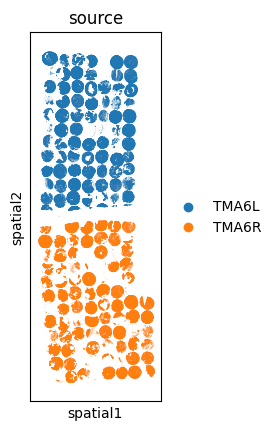

In [68]:
## current spatialmap

sc.pl.spatial(
    adata_merged,
    color='source',
    spot_size=20,
    cmap="viridis"
)

In [69]:
tx_L.head()

,x,y,z,feature_name,cell_id,is_gene,overlaps_nucleus,codeword_category,nucleus_distance,transcript_id,qv,fov_name,codeword_index
6576,221.171875,10699.171875,15.15625,COL11A1,oegpmppd-1,True,1,custom_gene,0.0,282535833633239,39.75,R2,157
6601,223.062500,10700.500000,16.09375,IGFBP4,oegpmppd-1,True,1,custom_gene,0.0,282535833633483,40.00,R2,135
6640,215.515625,10700.234375,16.03125,RCN2,oegpmppd-1,True,1,custom_gene,0.0,282535833633187,40.00,R2,405
6660,218.984375,10698.562500,16.31250,TIMP2,oegpmppd-1,True,1,custom_gene,0.0,282535833633704,40.00,R2,31
12098,278.234375,1920.203125,12.75000,CD4,oegnafja-1,True,1,custom_gene,0.0,281659660304621,40.00,F2,105


In [70]:
polys_L.head()

,cell_id,geometry
0,L_aaaaaipa-1,"POLYGON ((906.1 13767.875, 905.675 13768.088, ..."
1,L_aaaaamin-1,"POLYGON ((909.288 13752.15, 907.588 13753.426,..."
2,L_aaaabnpc-1,"POLYGON ((911.625 13785.938, 909.925 13786.788..."
3,L_aaaacmld-1,"POLYGON ((939.25 13868.812, 938.188 13869.45, ..."
4,L_aaaafgng-1,"POLYGON ((926.075 14046.25, 924.8 14046.676, 9..."


## Preparation of data

In [71]:
# Identify the transcript ID column
id_col = "transcript_id" if "transcript_id" in tx_L.columns else "id"

In [72]:
tx_L[id_col] = "L_" + tx_L[id_col].astype(str)
tx_R[id_col] = "R_" + tx_R[id_col].astype(str)

tx_L["cell_id"] = "L_" + tx_L["cell_id"].astype(str)
tx_R["cell_id"] = "R_" + tx_R["cell_id"].astype(str)


In [73]:
type(tx_L[id_col])


pandas.core.series.Series

In [74]:
# Align columns before merging
# Align columns
common_cols = tx_L.columns.intersection(tx_R.columns)
tx_L = tx_L[common_cols]
tx_R = tx_R[common_cols]

# Convert to Pandas
tx_L = tx_L.compute() if hasattr(tx_L, "compute") else tx_L
tx_R = tx_R.compute() if hasattr(tx_R, "compute") else tx_R

# Merge
tx_merged = pd.concat([tx_L, tx_R], ignore_index=True)


In [75]:
tx_merged.head()

,x,y,z,feature_name,cell_id,is_gene,overlaps_nucleus,codeword_category,nucleus_distance,transcript_id,qv,fov_name,codeword_index
0,221.171875,10699.171875,15.15625,COL11A1,L_oegpmppd-1,True,1,custom_gene,0.0,L_282535833633239,39.75,R2,157
1,223.062500,10700.500000,16.09375,IGFBP4,L_oegpmppd-1,True,1,custom_gene,0.0,L_282535833633483,40.00,R2,135
2,215.515625,10700.234375,16.03125,RCN2,L_oegpmppd-1,True,1,custom_gene,0.0,L_282535833633187,40.00,R2,405
3,218.984375,10698.562500,16.31250,TIMP2,L_oegpmppd-1,True,1,custom_gene,0.0,L_282535833633704,40.00,R2,31
4,278.234375,1920.203125,12.75000,CD4,L_oegnafja-1,True,1,custom_gene,0.0,L_281659660304621,40.00,F2,105


In [76]:
tx_merged.shape


(191222659, 13)

In [77]:
polys_merged = gpd.GeoDataFrame(
    pd.concat([polys_L, polys_R], ignore_index=True),
    geometry="geometry",
    crs=polys_L.crs
)


In [78]:
polys_merged.head()

,cell_id,geometry
0,L_aaaaaipa-1,"POLYGON ((906.1 13767.875, 905.675 13768.088, ..."
1,L_aaaaamin-1,"POLYGON ((909.288 13752.15, 907.588 13753.426,..."
2,L_aaaabnpc-1,"POLYGON ((911.625 13785.938, 909.925 13786.788..."
3,L_aaaacmld-1,"POLYGON ((939.25 13868.812, 938.188 13869.45, ..."
4,L_aaaafgng-1,"POLYGON ((926.075 14046.25, 924.8 14046.676, 9..."


In [79]:
polys_merged["cell_id"].is_unique


True

In [80]:
len(polys_L) + len(polys_R), len(polys_merged)


(1148591, 1148591)

### Input preparation

#### detected_transcripts

In [81]:
tx_merged

,x,y,z,feature_name,cell_id,is_gene,overlaps_nucleus,codeword_category,nucleus_distance,transcript_id,qv,fov_name,codeword_index
0,221.171875,10699.171875,15.156250,COL11A1,L_oegpmppd-1,True,1,custom_gene,0.000000,L_282535833633239,39.75,R2,157
1,223.062500,10700.500000,16.093750,IGFBP4,L_oegpmppd-1,True,1,custom_gene,0.000000,L_282535833633483,40.00,R2,135
2,215.515625,10700.234375,16.031250,RCN2,L_oegpmppd-1,True,1,custom_gene,0.000000,L_282535833633187,40.00,R2,405
3,218.984375,10698.562500,16.312500,TIMP2,L_oegpmppd-1,True,1,custom_gene,0.000000,L_282535833633704,40.00,R2,31
4,278.234375,1920.203125,12.750000,CD4,L_oegnafja-1,True,1,custom_gene,0.000000,L_281659660304621,40.00,F2,105
...,...,...,...,...,...,...,...,...,...,...,...,...,...
191222654,11275.890625,30499.951172,22.890625,NegControlCodeword_0528,R_legfoech-1,False,0,negative_control_codeword,0.296875,R_283042640066641,12.75,V19,528
191222655,11292.359375,30523.388672,25.468750,NegControlCodeword_0535,R_legfeljb-1,False,0,negative_control_codeword,1.578125,R_283042639860537,13.00,V19,535
191222656,11276.343750,30644.529297,22.500000,NegControlCodeword_0538,R_binimgjd-1,False,1,negative_control_codeword,0.000000,R_283042639879060,13.00,V19,538
191222657,11347.562500,30973.357422,20.703125,CAPS,R_ohjogmei-1,True,0,custom_gene,3.156250,R_283115654219104,40.00,W19,181


In [84]:
tx_merged = tx_merged[tx_merged["codeword_category"] == "custom_gene"].copy()


In [87]:
tx_merged["feature_name"].nunique()

480

In [88]:
transcripts_fg = tx_merged[tx_merged["cell_id"].notna()].copy()

detected_transcripts = pd.DataFrame({
    "global_x": transcripts_fg["x"],
    "global_y": transcripts_fg["y"],
    "gene": transcripts_fg["feature_name"],
    "cell_id": transcripts_fg["cell_id"].astype(str),
})


print(detected_transcripts.head())
print(detected_transcripts.shape)


     global_x      global_y     gene       cell_id
0  221.171875  10699.171875  COL11A1  L_oegpmppd-1
1  223.062500  10700.500000   IGFBP4  L_oegpmppd-1
2  215.515625  10700.234375     RCN2  L_oegpmppd-1
3  218.984375  10698.562500    TIMP2  L_oegpmppd-1
4  278.234375   1920.203125      CD4  L_oegnafja-1
(191143687, 4)


#### cell_metadata

In [90]:
adata_merged

AnnData object with n_obs × n_vars = 1148591 × 480
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'arrayID', 'tma', 'PatientID', 'Diagnosis', 'source'
    uns: 'source_colors'
    obsm: 'spatial'

In [94]:
x_min = adata_merged.obsm["spatial"][:,0].min()
x_max = adata_merged.obsm["spatial"][:,0].max()
y_min = adata_merged.obsm["spatial"][:,1].min()
y_max = adata_merged.obsm["spatial"][:,1].max()

x_min, x_max, y_min, y_max


(206.98741149902344, 11441.8037109375, 62.78565979003906, 31611.367630004883)

In [97]:
# building the cell_metadata

adata = adata_merged.copy()

cell_metadata = pd.DataFrame({
    "cell_id": adata_merged.obs["cell_id"].astype(str),
    "center_x": adata_merged.obsm["spatial"][:, 0],
    "center_y": adata_merged.obsm["spatial"][:, 1],
}).set_index("cell_id")

cell_metadata.tail()


,center_x,center_y
cell_id,,
R_oinakica-1,6109.225586,23012.564407
R_oinandgf-1,6063.650879,23079.005325
R_oinaoilg-1,6014.394531,23077.896439
R_oinbbkim-1,6016.321777,22901.254837
R_oinbcfpo-1,6018.327148,22896.301224


In [98]:
cell_metadata["center_y"].max()


31611.367630004883

#### cell_boundary_polygons

In [99]:
polys_merged.head()

,cell_id,geometry,cx,cy
0,L_aaaaaipa-1,"POLYGON ((906.1 13767.875, 905.675 13768.088, ...",908.381085,13773.097825
1,L_aaaaamin-1,"POLYGON ((909.288 13752.15, 907.588 13753.426,...",910.220811,13759.748085
2,L_aaaabnpc-1,"POLYGON ((911.625 13785.938, 909.925 13786.788...",909.990611,13793.838760
3,L_aaaacmld-1,"POLYGON ((939.25 13868.812, 938.188 13869.45, ...",943.303829,13875.094303
4,L_aaaafgng-1,"POLYGON ((926.075 14046.25, 924.8 14046.676, 9...",925.898435,14054.253349


In [100]:
polygons = polys_merged.copy()

# Keep string IDs
polygons["cell_id"] = polygons["cell_id"].astype(str)

# Rename geometry column
polygons = polygons.rename_geometry("polygon")

# Set index to cell_id
polygons = polygons.set_index("cell_id")

# Drop unused columns
polygons = polygons.drop(columns=["cx", "cy"], errors="ignore")

polygons.head()


,polygon
cell_id,
L_aaaaaipa-1,"POLYGON ((906.1 13767.875, 905.675 13768.088, ..."
L_aaaaamin-1,"POLYGON ((909.288 13752.15, 907.588 13753.426,..."
L_aaaabnpc-1,"POLYGON ((911.625 13785.938, 909.925 13786.788..."
L_aaaacmld-1,"POLYGON ((939.25 13868.812, 938.188 13869.45, ..."
L_aaaafgng-1,"POLYGON ((926.075 14046.25, 924.8 14046.676, 9..."


### Run MisTIC

#### Data importing

In [113]:
# ---------------------------------------------------------
# Drop transcripts with missing cell_id
# ---------------------------------------------------------
detected_transcripts = detected_transcripts[
    detected_transcripts["cell_id"].notna()
].copy()

# Clean transcript cell IDs (remove accidental ".0")
detected_transcripts["cell_id"] = (
    detected_transcripts["cell_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

# ---------------------------------------------------------
# Ensure all indices are strings
# ---------------------------------------------------------
cell_metadata.index = cell_metadata.index.astype(str)
polygons.index = polygons.index.astype(str)
cell_by_gene_counts.index = cell_by_gene_counts.index.astype(str)

# ---------------------------------------------------------
# Compute intersection across ALL modalities
# ---------------------------------------------------------
cells_tx = set(detected_transcripts["cell_id"])
cells_counts = set(cell_by_gene_counts.index)
cells_meta = set(cell_metadata.index)
cells_poly = set(polygons.index)

# Only keep cells present in ALL four tables
cells_intersection = cells_tx & cells_counts & cells_meta & cells_poly

print("Cells kept:", len(cells_intersection))
print("Dropped (tx only):", len(cells_tx - cells_intersection))
print("Dropped (counts only):", len(cells_counts - cells_intersection))
print("Dropped (meta only):", len(cells_meta - cells_intersection))
print("Dropped (poly only):", len(cells_poly - cells_intersection))

# Convert to list for indexing
cells_intersection_list = list(cells_intersection)

# ---------------------------------------------------------
# Filter all tables to the intersection
# ---------------------------------------------------------
cell_metadata_filtered = cell_metadata.loc[cells_intersection_list]
polygons_filtered = polygons.loc[cells_intersection_list]
cell_by_gene_counts_filtered = cell_by_gene_counts.loc[cells_intersection_list]

detected_transcripts_filtered = detected_transcripts[
    detected_transcripts["cell_id"].isin(cells_intersection)
]

# ---------------------------------------------------------
# Clean count matrix
# ---------------------------------------------------------
# Remove accidental cell_id column if present
cell_by_gene_counts_filtered = cell_by_gene_counts_filtered.drop(
    columns=["cell_id"], errors="ignore"
)

# Remove index name for MisTIC compatibility
cell_by_gene_counts_filtered.index.name = None

# ---------------------------------------------------------
# Save outputs
# ---------------------------------------------------------
cell_metadata_filtered.to_parquet("cell_metadata.parquet")
polygons_filtered.to_parquet("cell_boundary_polygons.parquet")
detected_transcripts_filtered.to_parquet("detected_transcripts.parquet")
cell_by_gene_counts_filtered.to_parquet("cell_by_gene_counts.parquet")


Cells kept: 1135770
Dropped (tx only): 0
Dropped (counts only): 12821
Dropped (meta only): 12821
Dropped (poly only): 12821


#### Object instantiation

In [3]:
m = mistic(
    cell_centroid_x_col='center_x',      
    cell_centroid_y_col='center_y',                      
    tx_x_col='global_x',                 
    tx_y_col='global_y',                 
    gene_col='gene',                     
    cell_col='cell_id',                  
)


In [4]:
cell_metadata = pd.read_parquet("cell_metadata.parquet")
cell_boundary_polygons = gpd.read_parquet("cell_boundary_polygons.parquet")
detected_transcripts = pd.read_parquet("detected_transcripts.parquet")


In [5]:
cell_metadata.index = cell_metadata.index.astype(str)
cell_metadata.columns = cell_metadata.columns.astype(str)
cell_boundary_polygons.index = cell_boundary_polygons.index.astype(str)
cell_boundary_polygons.columns = cell_boundary_polygons.columns.astype(str)
detected_transcripts["cell_id"] = detected_transcripts["cell_id"].astype(str)
detected_transcripts["gene"] = detected_transcripts["gene"].astype(str)
detected_transcripts.columns = detected_transcripts.columns.astype(str)


In [7]:
print("cell_metadata index dtype:", cell_metadata.index.dtype)
print("polygons index dtype:", cell_boundary_polygons.index.dtype)
print("tx cell_id dtype:", detected_transcripts["cell_id"].dtype)

print("Unique index counts:")
print("  metadata:", cell_metadata.index.nunique())
print("  polygons:", cell_boundary_polygons.index.nunique())
print("  transcripts:", detected_transcripts["cell_id"].nunique())


cell_metadata index dtype: object
polygons index dtype: object
tx cell_id dtype: object
Unique index counts:
  metadata: 1135770
  polygons: 1135770
  transcripts: 1135770


In [6]:
print("transcripts['gene'] dtype:", detected_transcripts["gene"].dtype)
print("Example gene values:", detected_transcripts["gene"].head().tolist())


transcripts['gene'] dtype: object
Example gene values: ['COL11A1', 'IGFBP4', 'RCN2', 'TIMP2', 'CD4']


In [8]:
print("metadata column types:", {type(c) for c in cell_metadata.columns})
print("polygon column types:", {type(c) for c in cell_boundary_polygons.columns})
print("transcript column types:", {type(c) for c in detected_transcripts.columns})


metadata column types: {<class 'str'>}
polygon column types: {<class 'str'>}
transcript column types: {<class 'str'>}


In [9]:
cells_meta = set(cell_metadata.index)
cells_poly = set(cell_boundary_polygons.index)
cells_tx = set(detected_transcripts["cell_id"])

print("Metadata only:", len(cells_meta - cells_tx))
print("Polygons only:", len(cells_poly - cells_tx))

Metadata only: 0
Polygons only: 0


In [10]:
print("NaNs in transcripts cell_id:", detected_transcripts["cell_id"].isna().sum())
print("NaNs in transcripts gene:", detected_transcripts["gene"].isna().sum())
print("NaNs in metadata:", cell_metadata.isna().sum().sum())

NaNs in transcripts cell_id: 0
NaNs in transcripts gene: 0
NaNs in metadata: 0


In [11]:
m.import_data(
    cell_metadata= cell_metadata,
    cell_boundary_polygons= cell_boundary_polygons,
    detected_transcripts= detected_transcripts
)

Processing cell metadata
RAM memory % used: 6.6
RAM Used (GB): 24.995196928
Done. Time taken is 0.0038 seconds.
Processing cell boundaries
RAM memory % used: 6.9
RAM Used (GB): 26.187616256
Done. Time taken is 3.1546 seconds.
Processing Transcript information 
RAM memory % used: 20.7
RAM Used (GB): 78.701305856
Done. Time taken is 159.1421 seconds.
Processing cell by gene matrix
RAM memory % used: 21.9
RAM Used (GB): 83.126132736
Done. Time taken is 92.2752 seconds.
Creating AnnData object
RAM memory % used: 24.2
RAM Used (GB): 92.108853248
Done. Time taken is 5.0856 seconds.
Successfully read in data. Performing basic transformation
Computing UMAP
RAM memory % used: 28.2
RAM Used (GB): 107.220291584
Done. Time taken is 1279.3232 seconds.
RAM memory % used: 28.2
RAM Used (GB): 107.220291584
Done. Time taken is 1285.2895 seconds.
Performing Leiden clustering.
RAM memory % used: 28.2
RAM Used (GB): 107.219566592
Done. Time taken is 8816.2607 seconds.
Adding meta info to adata
RAM memory 

Prepare for DE:   0%|          | 0/92 [00:00<?, ?it/s]

Generate pseudo-bulk for 0
RAM memory % used: 34.4
RAM Used (GB): 130.930573312
Done. Time taken is 3.4131 seconds.
Generate pseudo-bulk for 1
RAM memory % used: 34.5
RAM Used (GB): 131.33856768
Done. Time taken is 2.6101 seconds.
Generate pseudo-bulk for 10
RAM memory % used: 34.4
RAM Used (GB): 130.64105984
Done. Time taken is 1.2460 seconds.
Generate pseudo-bulk for 11
RAM memory % used: 34.3
RAM Used (GB): 130.240987136
Done. Time taken is 1.1819 seconds.
Generate pseudo-bulk for 12
RAM memory % used: 34.3
RAM Used (GB): 130.446368768
Done. Time taken is 1.1711 seconds.
Generate pseudo-bulk for 13
RAM memory % used: 34.2
RAM Used (GB): 130.174824448
Done. Time taken is 1.0594 seconds.
Generate pseudo-bulk for 14
RAM memory % used: 34.3
RAM Used (GB): 130.3580672
Done. Time taken is 1.0130 seconds.
Generate pseudo-bulk for 15
RAM memory % used: 34.2
RAM Used (GB): 129.953124352
Done. Time taken is 0.9758 seconds.
Generate pseudo-bulk for 16
RAM memory % used: 34.1
RAM Used (GB): 129

/homevol/kk/.local/lib/python3.9/site-packages/pydeseq2/dds.py:270: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(
Fitting size factors...
/homevol/kk/.local/lib/python3.9/site-packages/pydeseq2/dds.py:490: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors()
Fitting dispersions...
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 1.04 seconds.

Fitting dispersions...
... done in 0.19 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting dispersions...
... done in 0.19 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

/homevol/kk/miniconda3/envs/mistic/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be cau

RAM memory % used: 36.0
RAM Used (GB): 136.968761344
Done. Time taken is 3068.7953 seconds.
Performing one-vs-rest differential analysis...


... done in 0.17 seconds.

Replacing 0 outlier genes.



  0%|          | 0/92 [00:00<?, ?it/s]

When comparing rest to 37, some pvalues/padjs are NaN. We will fill it with 1.
When comparing rest to 58, some pvalues/padjs are NaN. We will fill it with 1.
RAM memory % used: 36.0
RAM Used (GB): 136.820105216
Done. Time taken is 75.0087 seconds.
Generate DE features
RAM memory % used: 36.0
RAM Used (GB): 136.820105216
Done. Time taken is 0.0205 seconds.
Prepare for prior DE
RAM memory % used: 37.1
RAM Used (GB): 141.218422784
Done. Time taken is 10.0294 seconds.
Find NNs
RAM memory % used: 37.9
RAM Used (GB): 144.01765376
Done. Time taken is 20.8548 seconds.


  0%|          | 0/1136 [00:00<?, ?it/s]

Add count information: chunk 0
RAM memory % used: 37.9
RAM Used (GB): 144.00540672
Done. Time taken is 0.4059 seconds.
Compute mean: chunk 0
RAM memory % used: 37.9
RAM Used (GB): 143.998304256
Done. Time taken is 0.0323 seconds.
Generate Features: chunk 0
RAM memory % used: 37.9
RAM Used (GB): 143.998554112
Done. Time taken is 0.2195 seconds.
Wide to long form : chunk 0
RAM memory % used: 37.9
RAM Used (GB): 144.006295552
Done. Time taken is 0.0118 seconds.
Add count information: chunk 1
RAM memory % used: 37.9
RAM Used (GB): 144.000282624
Done. Time taken is 0.4120 seconds.
Compute mean: chunk 1
RAM memory % used: 37.9
RAM Used (GB): 144.000282624
Done. Time taken is 0.0353 seconds.
Generate Features: chunk 1
RAM memory % used: 37.9
RAM Used (GB): 143.993565184
Done. Time taken is 0.2103 seconds.
Wide to long form : chunk 1
RAM memory % used: 37.9
RAM Used (GB): 144.001306624
Done. Time taken is 0.0154 seconds.
Add count information: chunk 2
RAM memory % used: 37.9
RAM Used (GB): 144

#### Model training

In [12]:

# ------------------------------------------------------------
# Prepare minibatches for SGD
# ------------------------------------------------------------
m.patchfy_data()

# ------------------------------------------------------------
# Initialize and train the model
# ------------------------------------------------------------
m.initialize_parameters()
m.training_loop(n_epochs=20)



neighbor1:   0%|          | 0/745 [00:00<?, ?it/s]

Train Epoch: 0 [0/745 (0%)]tLoss: 8.566285
Train Epoch: 0 [10/745 (1%)]tLoss: 7.526541
Train Epoch: 0 [20/745 (3%)]tLoss: 6.816363
Train Epoch: 0 [30/745 (4%)]tLoss: 5.961837
Train Epoch: 0 [40/745 (5%)]tLoss: 7.120380
Train Epoch: 0 [50/745 (7%)]tLoss: 5.499314
Train Epoch: 0 [60/745 (8%)]tLoss: 6.373534
Train Epoch: 0 [70/745 (9%)]tLoss: 4.948469
Train Epoch: 0 [80/745 (11%)]tLoss: 5.661869
Train Epoch: 0 [90/745 (12%)]tLoss: 5.116526
Train Epoch: 0 [100/745 (13%)]tLoss: 6.876263
Train Epoch: 0 [110/745 (15%)]tLoss: 5.047768
Train Epoch: 0 [120/745 (16%)]tLoss: 6.352350
Train Epoch: 0 [130/745 (17%)]tLoss: 4.948198
Train Epoch: 0 [140/745 (19%)]tLoss: 4.686642
Train Epoch: 0 [150/745 (20%)]tLoss: 4.347179
Train Epoch: 0 [160/745 (21%)]tLoss: 4.813997
Train Epoch: 0 [170/745 (23%)]tLoss: 5.261673
Train Epoch: 0 [180/745 (24%)]tLoss: 5.738181
Train Epoch: 0 [190/745 (26%)]tLoss: 4.682247
Train Epoch: 0 [200/745 (27%)]tLoss: 4.978995
Train Epoch: 0 [210/745 (28%)]tLoss: 5.336092
Train E

neighbor0:   0%|          | 0/1005 [00:00<?, ?it/s]

Train Epoch: 0 [0/1005 (0%)]tLoss: 5.201512
Train Epoch: 0 [10/1005 (1%)]tLoss: 5.106852
Train Epoch: 0 [20/1005 (2%)]tLoss: 3.501455
Train Epoch: 0 [30/1005 (3%)]tLoss: 3.514206
Train Epoch: 0 [40/1005 (4%)]tLoss: 4.603454
Train Epoch: 0 [50/1005 (5%)]tLoss: 4.139223
Train Epoch: 0 [60/1005 (6%)]tLoss: 3.377005
Train Epoch: 0 [70/1005 (7%)]tLoss: 3.488019
Train Epoch: 0 [80/1005 (8%)]tLoss: 5.126505
Train Epoch: 0 [90/1005 (9%)]tLoss: 4.738400
Train Epoch: 0 [100/1005 (10%)]tLoss: 4.602703
Train Epoch: 0 [110/1005 (11%)]tLoss: 5.092421
Train Epoch: 0 [120/1005 (12%)]tLoss: 3.886240
Train Epoch: 0 [130/1005 (13%)]tLoss: 4.141257
Train Epoch: 0 [140/1005 (14%)]tLoss: 5.518526
Train Epoch: 0 [150/1005 (15%)]tLoss: 4.568990
Train Epoch: 0 [160/1005 (16%)]tLoss: 4.277297
Train Epoch: 0 [170/1005 (17%)]tLoss: 3.074452
Train Epoch: 0 [180/1005 (18%)]tLoss: 4.431700
Train Epoch: 0 [190/1005 (19%)]tLoss: 3.965266
Train Epoch: 0 [200/1005 (20%)]tLoss: 4.471907
Train Epoch: 0 [210/1005 (21%)]tLo

neighbor2:   0%|          | 0/678 [00:00<?, ?it/s]

...

Train Epoch: 7 [0/1005 (0%)]tLoss: 2.913458
Train Epoch: 7 [10/1005 (1%)]tLoss: 3.034086
Train Epoch: 7 [20/1005 (2%)]tLoss: 3.165639
Train Epoch: 7 [30/1005 (3%)]tLoss: 3.724451
Train Epoch: 7 [40/1005 (4%)]tLoss: 3.001830
Train Epoch: 7 [50/1005 (5%)]tLoss: 3.561797
Train Epoch: 7 [60/1005 (6%)]tLoss: 3.025234
Train Epoch: 7 [70/1005 (7%)]tLoss: 2.909659
Train Epoch: 7 [80/1005 (8%)]tLoss: 3.628593
Train Epoch: 7 [90/1005 (9%)]tLoss: 3.369753
Train Epoch: 7 [100/1005 (10%)]tLoss: 2.891760
Train Epoch: 7 [110/1005 (11%)]tLoss: 3.066466
Train Epoch: 7 [120/1005 (12%)]tLoss: 3.378875
Train Epoch: 7 [130/1005 (13%)]tLoss: 3.406466
Train Epoch: 7 [140/1005 (14%)]tLoss: 3.050393
Train Epoch: 7 [150/1005 (15%)]tLoss: 3.247247
Train Epoch: 7 [160/1005 (16%)]tLoss: 4.040398
Train Epoch: 7 [170/1005 (17%)]tLoss: 3.398173
Train Epoch: 7 [180/1005 (18%)]tLoss: 2.843295
Train Epoch: 7 [190/1005 (19%)]tLoss: 3.427778
Train Epoch: 7 [200/1005 (20%)]tLoss: 2.825068
Train Epoch: 7 [210/1005 (21%)]tLo

neighbor2:   0%|          | 0/678 [00:00<?, ?it/s]

Train Epoch: 7 [0/678 (0%)]tLoss: 3.865806
Train Epoch: 7 [10/678 (1%)]tLoss: 3.686019
Train Epoch: 7 [20/678 (3%)]tLoss: 3.750618
Train Epoch: 7 [30/678 (4%)]tLoss: 3.521509
Train Epoch: 7 [40/678 (6%)]tLoss: 3.614192
Train Epoch: 7 [50/678 (7%)]tLoss: 3.578953
Train Epoch: 7 [60/678 (9%)]tLoss: 3.743671
Train Epoch: 7 [70/678 (10%)]tLoss: 3.422382
Train Epoch: 7 [80/678 (12%)]tLoss: 3.464098
Train Epoch: 7 [90/678 (13%)]tLoss: 3.841085
Train Epoch: 7 [100/678 (15%)]tLoss: 3.385928
Train Epoch: 7 [110/678 (16%)]tLoss: 3.484453
Train Epoch: 7 [120/678 (18%)]tLoss: 3.298067
Train Epoch: 7 [130/678 (19%)]tLoss: 3.801779
Train Epoch: 7 [140/678 (21%)]tLoss: 3.749058
Train Epoch: 7 [150/678 (22%)]tLoss: 3.581004
Train Epoch: 7 [160/678 (24%)]tLoss: 4.069290
Train Epoch: 7 [170/678 (25%)]tLoss: 3.394446
Train Epoch: 7 [180/678 (27%)]tLoss: 3.398049
Train Epoch: 7 [190/678 (28%)]tLoss: 3.600972
Train Epoch: 7 [200/678 (29%)]tLoss: 3.126958
Train Epoch: 7 [210/678 (31%)]tLoss: 3.555171
Train 

neighbor1:   0%|          | 0/745 [00:00<?, ?it/s]

Train Epoch: 7 [0/745 (0%)]tLoss: 3.413014
Train Epoch: 7 [10/745 (1%)]tLoss: 3.749329
Train Epoch: 7 [20/745 (3%)]tLoss: 4.315441
Train Epoch: 7 [30/745 (4%)]tLoss: 3.575549
Train Epoch: 7 [40/745 (5%)]tLoss: 3.119074
Train Epoch: 7 [50/745 (7%)]tLoss: 3.466369
Train Epoch: 7 [60/745 (8%)]tLoss: 3.472856
Train Epoch: 7 [70/745 (9%)]tLoss: 3.615946
Train Epoch: 7 [80/745 (11%)]tLoss: 3.862503
Train Epoch: 7 [90/745 (12%)]tLoss: 3.531377
Train Epoch: 7 [100/745 (13%)]tLoss: 3.332843
Train Epoch: 7 [110/745 (15%)]tLoss: 3.349100
Train Epoch: 7 [120/745 (16%)]tLoss: 3.374975
Train Epoch: 7 [130/745 (17%)]tLoss: 3.389928
Train Epoch: 7 [140/745 (19%)]tLoss: 3.391165
Train Epoch: 7 [150/745 (20%)]tLoss: 3.129628
Train Epoch: 7 [160/745 (21%)]tLoss: 3.430551
Train Epoch: 7 [170/745 (23%)]tLoss: 3.157513
Train Epoch: 7 [180/745 (24%)]tLoss: 3.610516
Train Epoch: 7 [190/745 (26%)]tLoss: 3.372341
Train Epoch: 7 [200/745 (27%)]tLoss: 3.134362
Train Epoch: 7 [210/745 (28%)]tLoss: 3.107967
Train E

#### Transcript misassignment correction

In [13]:
# ------------------------------------------------------------
# Compute reassignment probabilities
# ------------------------------------------------------------
m.compute_reassign_probs()

# ------------------------------------------------------------
# Correct transcript assignments
# ------------------------------------------------------------
m.correct_tx(
    reassign_threshold_grid=np.arange(0.1, 0.6, 0.1),
    remove_threshold_grid=np.arange(0.0, 0.4, 0.1),
    choice_type="best" 
)


  0%|          | 0/100 [00:00<?, ?it/s]

Reassign grid:   0%|          | 0/5 [00:00<?, ?it/s]

Remove grid:   0%|          | 0/4 [00:00<?, ?it/s]

Remove grid:   0%|          | 0/4 [00:00<?, ?it/s]

Remove grid:   0%|          | 0/4 [00:00<?, ?it/s]

Remove grid:   0%|          | 0/4 [00:00<?, ?it/s]

Remove grid:   0%|          | 0/4 [00:00<?, ?it/s]

Updating gene counts


/homevol/kk/.local/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:233: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


Computing UMAP
RAM memory % used: 49.3
RAM Used (GB): 187.259334656
Done. Time taken is 1191.4604 seconds.
RAM memory % used: 49.3
RAM Used (GB): 187.259334656
Done. Time taken is 1226.2766 seconds.


#### Model saving

In [16]:
# ------------------------------------------------------------
# Save the model + correction results
# ------------------------------------------------------------
m.save_model(
    dir_name="tma6",
    model_name="mistic",
    save_correction_result=True
)


#### Inspect outputs

In [17]:
tx_remove = pd.read_parquet("tma6/mistic_tx_to_remove.parquet")
tx_remove.head()

,molecule_id,from_cell_id,gene,neighbor_cell_id,neighbor_index,distance_feature,exp_feature,neighbor_exp_feature,reassign_probs_raw,reassign_probs,from_cell_type
0,tx_70915831,L_jmbmgank-1,TRMT112,L_jmbmkegf-1,0,1.459114,-0.043632,0.878657,6.293973e-07,0.198896,3
1,tx_163579443,R_jcjijidb-1,KRT19,R_jcjkkcfd-1,0,1.954940,2.802416,-1.900627,1.605208e-07,0.170416,10
2,tx_34195968,L_hmilijpj-1,TAGLN,L_hmileakc-1,0,3.320228,-2.130751,3.368331,5.920301e-07,0.197524,0
3,tx_74105624,L_kamaffaj-1,IGFBP5,L_kamafimo-1,0,1.392886,-2.575035,3.506159,3.655077e-08,0.144154,3
4,tx_181107100,R_djknlfcn-1,CFD,R_djknddop-1,0,0.647131,-1.066896,2.175402,3.483979e-07,0.186027,3


In [18]:
tx_reassign = pd.read_parquet("tma6/mistic_tx_to_reassign.parquet")
tx_reassign.head()

,molecule_id,from_cell_id,gene,to_cell_id,neighbor_index,distance_feature,exp_feature,neighbor_exp_feature,reassign_probs_raw,reassign_probs,from_cell_type,to_cell_type
0,tx_52607569,L_beifpojc-1,TNFSF10,L_beighjjh-1,1,0.586872,-0.503552,2.221699,0.000002,0.226370,10,9
1,tx_11159192,L_ejdopjhn-1,LIPH,L_dccpfpib-1,0,0.221401,1.488480,1.179282,0.000033,0.311161,1,30
2,tx_122943294,R_jnkijndo-1,MSH6,R_jnkincaj-1,0,1.232077,-0.363940,2.398987,0.000007,0.262049,17,7
3,tx_161362515,R_dphdaaen-1,COL6A1,R_dphdggnb-1,0,2.833213,-0.441956,2.454810,0.000023,0.298189,1,5
4,tx_131017456,R_aachgbid-1,KRT19,R_gneapoln-1,0,2.498349,0.785259,3.085574,0.001525,0.480191,29,2


In [ ]:
import json
with open("tma6/mistic_meta.json") as f:
    meta = json.load(f)
meta


In [19]:
crit = pd.read_csv("tma6/mistic_criteria_df.csv")
crit.sort_values("loss").head()


,reassign_threshold,remove_threshold_percent,loss,n_removed,remove_threshold,loss_increase
0,0.2,0.3,0.224355,16408126,0.14,0.000000
1,0.2,0.2,0.225234,9433612,0.16,0.003920
2,0.2,0.1,0.232366,4079395,0.18,0.035706
3,0.2,0.0,0.241503,0,0.20,0.076434
4,0.3,0.3,0.247638,8610043,0.21,0.103779


### Readjust the counts

In [ ]:
adata_merged

In [49]:
def apply_mistic_corrections(adata, tx_reassign):
    import numpy as np
    import scipy.sparse as sp

    X = adata.X
    if sp.issparse(X):
        X = X.tolil()
    else:
        X = sp.lil_matrix(X)

    X = X.astype(np.int64)

    cell_to_idx = {cell: i for i, cell in enumerate(adata.obs_names)}
    gene_to_idx = {gene: j for j, gene in enumerate(adata.var_names)}

    # Reassignments
    moves = (
        tx_reassign.groupby(["from_cell_id", "to_cell_id", "gene"])
        .size()
        .reset_index(name="n")
    )

    for _, row in moves.iterrows():
        j = gene_to_idx.get(row["gene"])
        if j is None:
            continue

        i_old = cell_to_idx.get(str(row["from_cell_id"]))
        i_new = cell_to_idx.get(str(row["to_cell_id"]))

        if i_old is not None:
            X[i_old, j] = max(0, X[i_old, j] - row["n"])
        if i_new is not None:
            X[i_new, j] += row["n"]

    adata.X = X.tocsr()
    return adata


In [50]:
tx_reassign = pd.read_parquet("tma6/mistic_tx_to_reassign.parquet")

adata_merged_corrected = apply_mistic_corrections(
    adata=adata_merged.copy(),
    tx_reassign=tx_reassign
)

In [51]:
print("tx_reassign:", len(tx_reassign))

print("any matching cell IDs:", len(set(tx_reassign["from_cell_id"]).intersection(adata_merged.obs_names)))
print("any matching genes:", len(set(tx_reassign["gene"]).intersection(adata_merged.var_names)))


tx_reassign: 16923756
any matching cell IDs: 753984
any matching genes: 480


In [52]:
before_cell = np.asarray(adata_merged.X.sum(axis=1)).ravel()
after_cell  = np.asarray(adata_merged_corrected.X.sum(axis=1)).ravel()

cell_df = pd.DataFrame({
    "before": before_cell,
    "after": after_cell
}, index=adata_merged.obs_names)

cell_df["delta"] = cell_df["after"] - cell_df["before"]
cell_df.sort_values("delta", ascending=False).head()


,before,after,delta
cell_id,,,
L_gahjdoac-1,121.0,995,874.0
R_daeplidb-1,449.0,1244,795.0
L_mflblffa-1,556.0,1259,703.0
R_dphjojpa-1,680.0,1381,701.0
R_dohanjic-1,77.0,761,684.0


In [56]:
before_gene = np.asarray(adata_merged.X.sum(axis=0)).ravel()
after_gene  = np.asarray(adata_merged_corrected.X.sum(axis=0)).ravel()

gene_df = pd.DataFrame({
    "before": before_gene,
    "after": after_gene
}, index=aadata_merged.var_names)

gene_df["delta"] = gene_df["after"] - gene_df["before"]
gene_df.sort_values("delta").head()


,before,after,delta
AADAC,142333.0,142333,0.0
NLRP12,12795.0,12795,0.0
NLGN1,52550.0,52550,0.0
NKG7,40462.0,40462,0.0
NID2,139545.0,139545,0.0


In [57]:
adata_merged_corrected.write_h5ad("tma6_xenium_clean_mistic.h5ad")